# LRD wind-profile diagnostic plot — tiring_solver (f-grid) models

The tiring fractions are $m = \{0.60, 0.90, 0.94\}$. These correspond to $\Gamma_0 = \{1.333, 1.222, 1.213\}$. Models generated by `solve_f_grid.py` → `generate_model_1d_f.py`.

In [1]:
import numpy as np
import wind_scales                 # one definition of r_sph (Mdot-dependent)
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})
MODELS = Path('../winds/runs_f/models')
FIGDIR = Path('../figures')
FIGDIR.mkdir(exist_ok=True)
from matplotlib.lines import Line2D
from matplotlib.ticker import LogLocator


## Load curves and locate $\tau_{\rm es}=1$ index for each

In [2]:
# Most-tired family first, so it takes the lightest blue (as the old
# notebook's Γ₀-ascending order did).
F_LIST    = [0.94, 0.90, 0.60]
Mdot_grid = [2.5, 5.0, 10.0, 15.0]
# Heavier Mdot -> more solid: 15 '-', 10 '--', 5 '-.', 2.5 ':'
linestyles = {15.0: '-', 10.0: '--', 5.0: '-.', 2.5: ':'}
blue_cmap = plt.cm.Blues(np.linspace(0.42, 0.95, len(F_LIST)))

all_curves = {}
fam = {}
for Mdot in Mdot_grid:
    all_curves[Mdot] = {}
    for F in F_LIST:
        d = np.load(MODELS / f"f{F:.2f}_Mdot{Mdot:.1f}.npz")
        R   = float(d['R'])
        r_n = d['r'] / R       # r / r_sph
        v_k = d['v'] / 1e5     # km/s
        rho = d['rho']         # g/cm^3
        tau = d['tau']         # Thomson
        idx = int(np.argmin(np.abs(tau - 1.0)))
        all_curves[Mdot][F] = {'r': r_n, 'v': v_k, 'rho': rho, 'tau': tau,
                               'idx_tau1': idx, 'R': R}
        fam[F] = {'f': float(d['f']), 'Gamma_0': float(d['Gamma_0']),
                  'm': float(d['m']), 'w1': float(d['w1'])}

for F in F_LIST:
    print(f"f={F}: Γ₀={fam[F]['Gamma_0']:.4f}  m={fam[F]['m']:.4f}  "
          f"w1={fam[F]['w1']:.3e}  v∞/v_esc={np.sqrt(fam[F]['w1']):.3f}")

f=0.94: Γ₀=1.2128  m=0.1649  w1=2.513e-03  v∞/v_esc=0.050
f=0.9: Γ₀=1.2222  m=0.1636  w1=7.224e-03  v∞/v_esc=0.085
f=0.6: Γ₀=1.3333  m=0.1500  w1=1.045e-01  v∞/v_esc=0.323


## Helpers

In [3]:
def plot_with_photosphere(ax, x, y, idx, color, ls, lw=2.0, zorder=5):
    # Plot curve solid up to idx, faded after; scatter point at idx marks τ_es=1.
    ax.plot(x[:idx+1], y[:idx+1], color=color, lw=lw, linestyle=ls, zorder=zorder)
    ax.plot(x[idx:],   y[idx:],   color=color, lw=lw, linestyle=ls,
            alpha=0.30, zorder=zorder)
    ax.scatter([x[idx]], [y[idx]], s=45, facecolor=color, edgecolor='black',
               linewidth=0.6, zorder=zorder+2)

## Stacked version with analytic marginally-unbound profiles overlaid

Same wind profiles, with the analytic *marginally-unbound* (MB) curves added in orange. The MB wind moves at the local escape speed and $\rho \propto r^{-3/2}$ by mass conservation:
$$v_{\rm esc}^{\rm (mb)}(r) \approx 515\,{\rm km\,s^{-1}}\left(\tfrac{M}{10^6\,M_\odot}\right)^{1/2}\left(\tfrac{r}{10^{16}\,{\rm cm}}\right)^{-1/2}, \quad \rho^{\rm (mb)}(r) \approx 10^{-16}\,{\rm g\,cm^{-3}}\left(\tfrac{\dot M}{10\,M_\odot/{\rm yr}}\right)\left(\tfrac{M}{10^6\,M_\odot}\right)^{-1/2}\left(\tfrac{r}{10^{16}\,{\rm cm}}\right)^{-3/2}$$
$$r_{\rm sca}^{\rm (mb)} \approx 4\times10^{17}\,{\rm cm}\,\left(\tfrac{\dot M}{10\,M_\odot/{\rm yr}}\right)^{2}\left(\tfrac{M}{10^6\,M_\odot}\right)^{-1}$$

MB curves are normalized by the **new** heating radius $r_{\rm sph} = \dot M G M_{\rm BH}/(0.2 L_{\rm Edd})$ so they share the x-axis with the photon-tired curves.

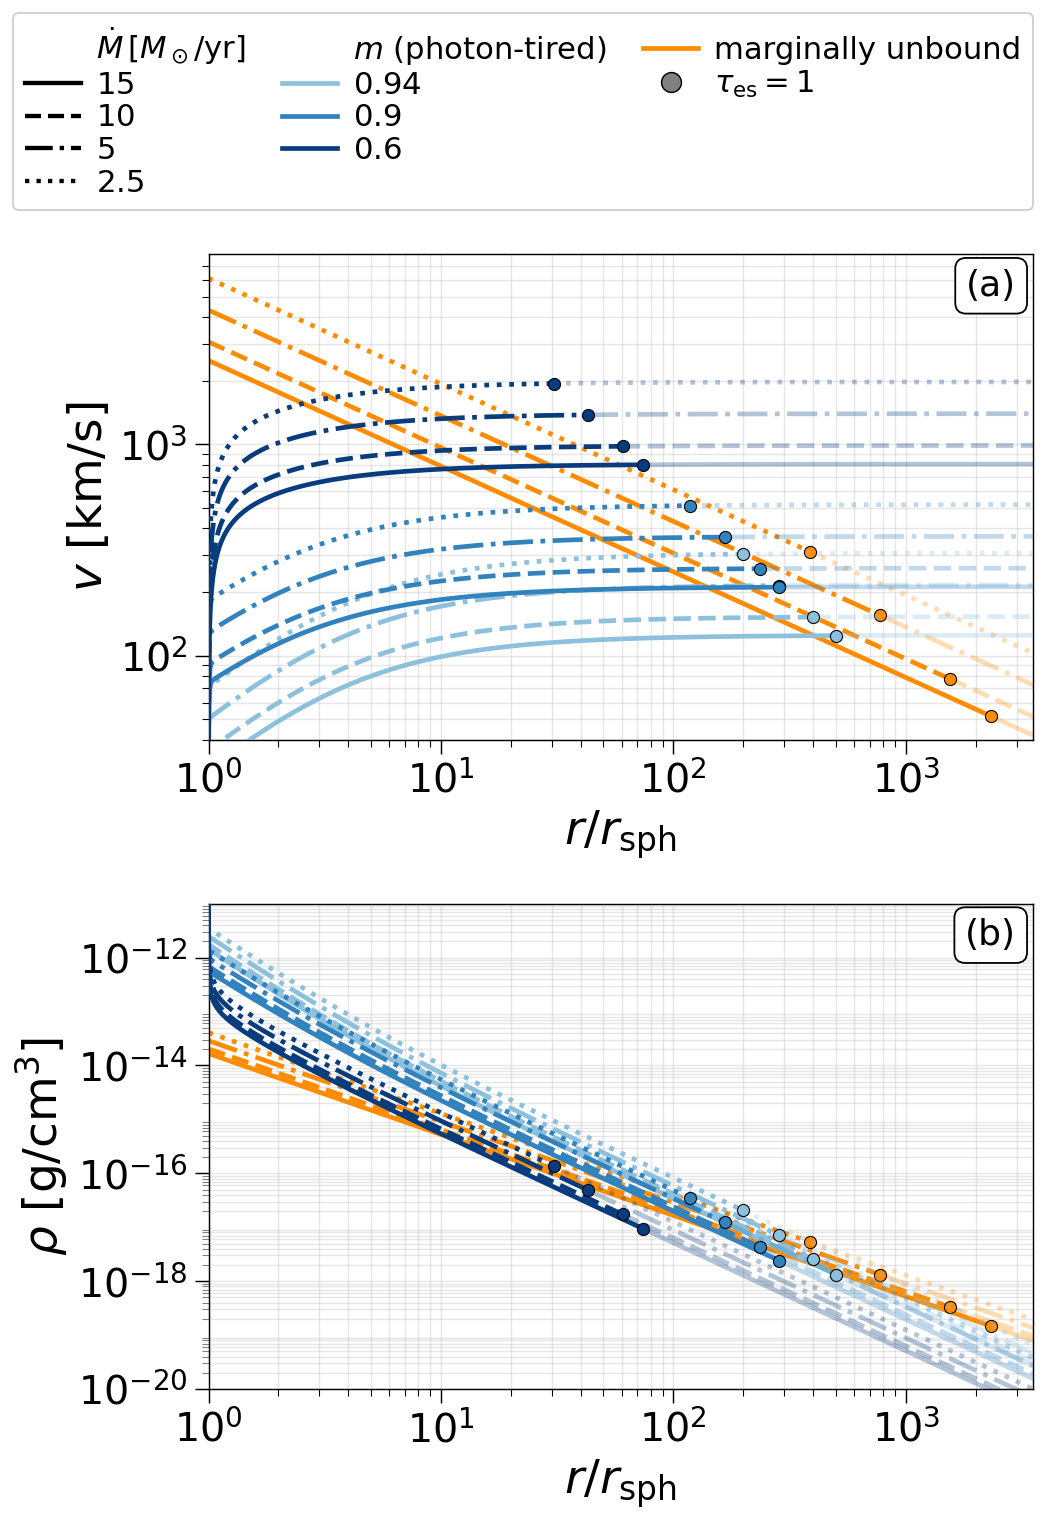

In [4]:
# Stacked (2x1) with MB overlay — for single-column placement in a 2-column PDF.
# Font sizes scaled up so they remain readable at ~half-page-width rendering.
G_cgs, Msun, yr, c_cgs = 6.674e-8, 1.989e33, 3.156e7, 2.998e10
M_BH, kappa = 1e6 * Msun, 0.34
L_Edd = 4 * np.pi * G_cgs * M_BH * c_cgs / kappa

M_NORM   = 1.0           # M / 1e6 M_sun
MB_COLOR = 'darkorange'
MB_RMAX  = 2e19          # cm; must exceed 1e19/r_sph(10)*r_sph(15) so all four
                         # marginally-unbound curves span the plotted x-range

# r_sph comes from wind_scales.py so one convention serves every figure
# (numerically identical to the local definition it replaces).
def r_sph(Mdot_Msun):
    return float(wind_scales.r_sph(Mdot_Msun))

def mb_profile(Mdot):
    """Analytic marginally-unbound wind:  v = v_esc(r),  rho = Mdot / (4 pi r^2 v).

    Evaluated directly from the constants above rather than from the paper's
    rounded prefactors (Eqs. 17-18, both normalised at r = 1e17 cm:
        v   = 515 km/s   (M/1e6)^( 1/2) (r/1e17)^(-1/2)
        rho = 5e-17 g/cm^3 (Mdot/5) (M/1e6)^(-1/2) (r/1e17)^(-3/2) ),
    so that the plotted curves satisfy Mdot = 4 pi r^2 rho v identically.

    The fully-ionised scattering photosphere follows from
        tau_es(r) = int_r^inf kappa rho dr' = kappa Mdot / (2 pi sqrt(2 G M r)),
    so tau_es = 1 at
        r_sca   = [kappa Mdot / (2 pi sqrt(2 G M))]^2
                = 1.1e18 cm (Mdot/5)^2 (M/1e6)^(-1),
        v(r_sca) = 156 km/s (Mdot/5)^(-1) (M/1e6),
    which is the normalisation of the v_ph column of the paper's Table 1.

    Returns dict with r_n (r/r_sph), v [km/s], rho [g/cm^3], idx of r_sca."""
    M      = M_NORM * M_BH
    GM     = G_cgs * M
    Mdot_g = Mdot * Msun / yr
    R_run  = r_sph(Mdot)
    r_cm   = np.logspace(np.log10(R_run), np.log10(MB_RMAX), 400)
    v_cm   = np.sqrt(2 * GM / r_cm)
    rho    = Mdot_g / (4 * np.pi * r_cm**2 * v_cm)
    r_sca  = (kappa * Mdot_g / (2 * np.pi * np.sqrt(2 * GM))) ** 2
    idx    = int(np.argmin(np.abs(r_cm - r_sca)))
    return dict(r_n=r_cm/R_run, v=v_cm/1e5, rho=rho, r_sca=r_sca, idx=idx)

FONT_SCALE = {
    'font.size':       22,
    'axes.labelsize':  26,
    'axes.titlesize':  26,
    'xtick.labelsize': 22,
    'ytick.labelsize': 22,
    'legend.fontsize': 18,
    'xtick.major.size': 8, 'xtick.minor.size': 4,
    'ytick.major.size': 8, 'ytick.minor.size': 4,
    'lines.linewidth': 2.6,
}

with plt.rc_context(FONT_SCALE):
    fig, (ax_v, ax_rho) = plt.subplots(2, 1, figsize=(8.5, 12))

    for j, F in enumerate(F_LIST):
        color = blue_cmap[j]
        for Mdot in Mdot_grid:
            c  = all_curves[Mdot][F]
            ls = linestyles[Mdot]
            plot_with_photosphere(ax_v,   c['r'], c['v'],   c['idx_tau1'], color, ls, lw=2.6)
            plot_with_photosphere(ax_rho, c['r'], c['rho'], c['idx_tau1'], color, ls, lw=2.6)

    mb_all = {Mdot: mb_profile(Mdot) for Mdot in Mdot_grid}
    for Mdot in Mdot_grid:
        p  = mb_all[Mdot]
        ls = linestyles[Mdot]
        plot_with_photosphere(ax_v,   p['r_n'], p['v'],   p['idx'], MB_COLOR, ls, lw=2.6, zorder=2)
        plot_with_photosphere(ax_rho, p['r_n'], p['rho'], p['idx'], MB_COLOR, ls, lw=2.6, zorder=2)

    R_ref       = all_curves[10.0][F_LIST[0]]['R']
    # y-range must cover the marginally-unbound curves too: they launch at
    # v_esc(r_sph) = 2500-6100 km/s, above the photon-tired maximum.
    v_max_plot  = max(max(max(d['v'].max() for d in all_curves[M].values())
                          for M in Mdot_grid),
                      max(p['v'].max() for p in mb_all.values()))
    v_low_floor = 40.0   # below v(r_sca)=51.7 km/s of the Mdot=15 marginally-unbound wind
    ax_v.set(xscale='log', yscale='log',
             xlabel=r'$r/r_{\rm sph}$', ylabel=r'$v$ [km/s]',
             xlim=(1.0, 1e19/R_ref),
             ylim=(v_low_floor, v_max_plot * 1.3))
    ax_v.grid(alpha=0.3, which='both', zorder=0)
    ax_rho.set(xscale='log', yscale='log',
               xlabel=r'$r/r_{\rm sph}$', ylabel=r'$\rho$ [g/cm$^3$]',
               xlim=(1.0, 1e19/R_ref),
               ylim=(1e-20, 1e-11))
    ax_rho.grid(alpha=0.3, which='both', zorder=0)

    # 3-column legend: col1 = Ṁ, col2 = f (photon tired), col3 = markers.
    hdr = lambda label: Line2D([0], [0], color='none', linewidth=0, marker='', label=label)
    tau_handle = Line2D([0], [0], marker='o', linestyle='', markersize=11,
                        markerfacecolor='gray', markeredgecolor='black',
                        markeredgewidth=0.8, label=r'$\tau_{\rm es}=1$')
    mb_handle  = Line2D([0], [0], color=MB_COLOR, lw=2.6, label='marginally unbound')
    mdot_desc  = sorted(Mdot_grid, reverse=True)
    handles = [
        hdr(r'$\dot M\,[M_\odot/\mathrm{yr}]$'),
        *[Line2D([0], [0], color='black', lw=2.4, linestyle=linestyles[M],
                 label=rf'${M:g}$') for M in mdot_desc],
        hdr(r'$m$ (photon-tired)'),
        *[Line2D([0], [0], color=blue_cmap[j], lw=2.6,
                 label=rf'${F:g}$') for j, F in enumerate(F_LIST)],
        hdr(''),
        mb_handle, tau_handle, hdr(''), hdr(''), hdr(''),
    ]
    fig.legend(handles=handles, ncol=3, loc='upper center',
               bbox_to_anchor=(0.5, 0.995), fontsize=17,
               framealpha=0.95, columnspacing=1.2, handlelength=1.8,
               handletextpad=0.5, borderaxespad=0.4, labelspacing=0.12)

    ax_rho.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10), numticks=100))
    ax_rho.tick_params(axis='y', which='minor', length=4, color='gray')

    # panel label top-right: the top-left is now the launch point of the
    # Mdot=2.5 marginally-unbound curve (v_esc(r_sph) = 6111 km/s).
    ax_v.text(0.98, 0.97, '(a)', transform=ax_v.transAxes,
              fontsize=20, ha='right', va='top',
              bbox=dict(facecolor='white', boxstyle='round'))
    ax_rho.text(0.98, 0.97, '(b)', transform=ax_rho.transAxes,
                fontsize=20, ha='right', va='top',
                bbox=dict(facecolor='white', boxstyle='round'))

    plt.tight_layout(rect=[0, 0, 1, 0.86])  # leave headroom for fig.legend
    plt.savefig(FIGDIR / 'FigPhotonTiredAndMBProfiles.png', dpi=180, bbox_inches='tight')
    plt.savefig(FIGDIR / 'FigPhotonTiredAndMBProfiles.pdf', bbox_inches='tight')
    plt.show()